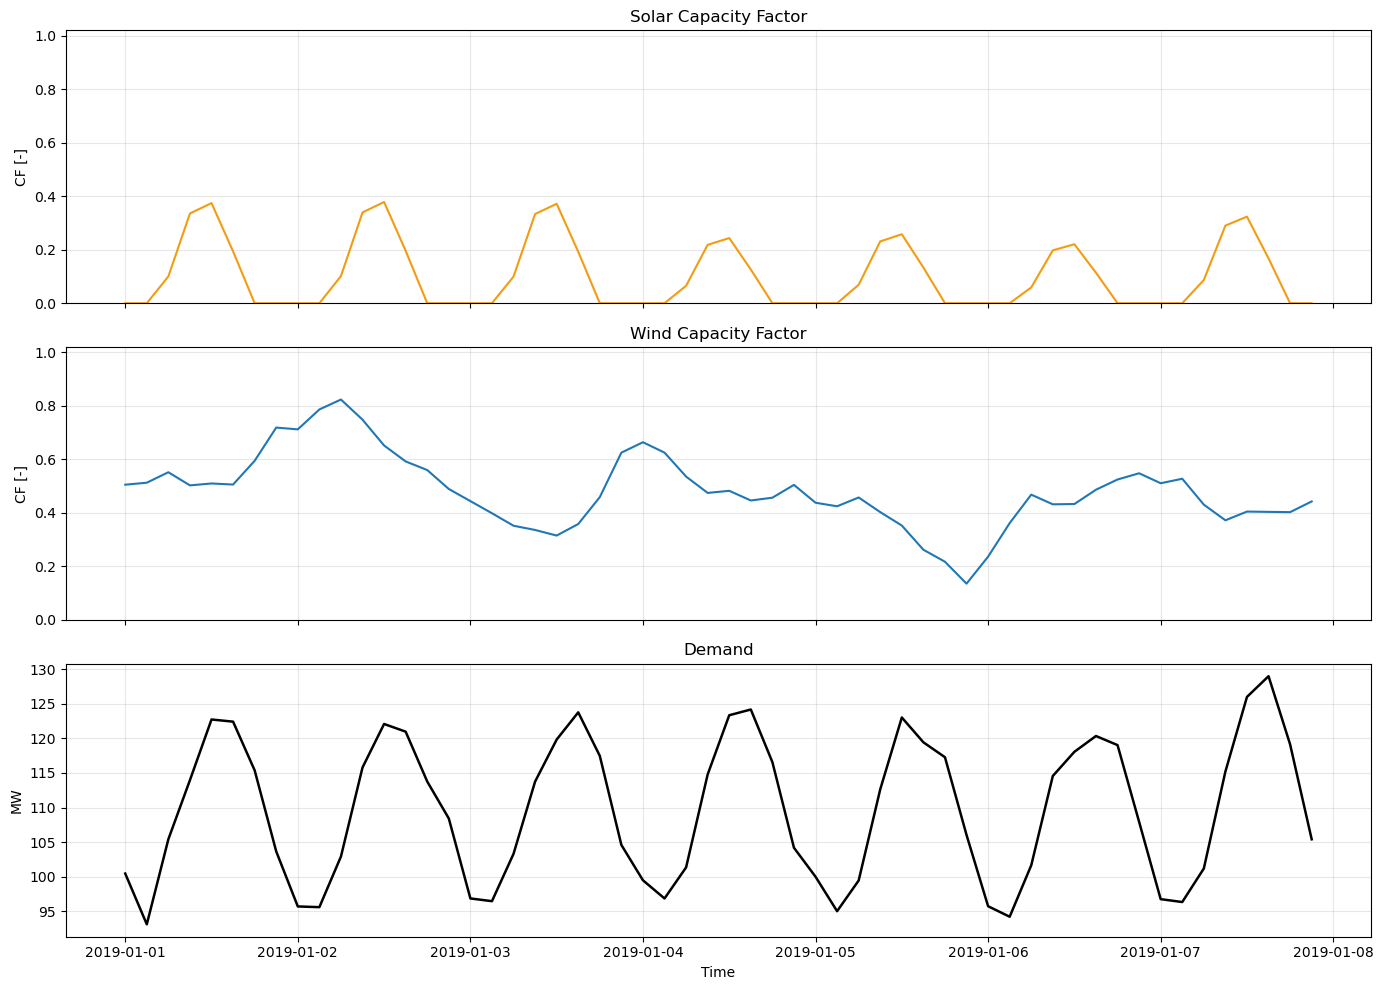

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def build_profiles(step_stride: int = 1) -> pd.DataFrame:
    idx = pd.date_range("2019-01-01", periods=8760, freq="h")
    h = np.asarray(idx.hour)
    doy = np.asarray(idx.dayofyear)
    rng = np.random.default_rng(2024)

    load = (
        100
        + 15 * np.sin(2 * np.pi * (h - 9) / 24)
        + 10 * np.cos(2 * np.pi * (doy - 20) / 365)
    )
    load = load * (1 + 0.03 * rng.standard_normal(8760))

    daylight = np.clip(np.sin(np.pi * (h - 6) / 12), 0, None)
    season = 0.75 + 0.25 * np.sin(2 * np.pi * (doy - 80) / 365)
    cloud = np.clip(
        1
        - 0.5
        * np.abs(
            pd.Series(rng.standard_normal(365))
            .rolling(3, min_periods=1)
            .mean()
            .to_numpy()
        )[doy - 1],
        0.2,
        1,
    )
    solar = np.clip(0.85 * daylight * season * cloud, 0, 1)

    z = np.zeros(8760)
    e = rng.standard_normal(8760)
    for t in range(1, 8760):
        z[t] = 0.97 * z[t - 1] + 0.25 * e[t]
    wind = np.clip(
        0.35
        + 0.15 * z
        + 0.08 * np.cos(2 * np.pi * (doy - 10) / 365)
        + 0.05 * np.cos(2 * np.pi * h / 24),
        0,
        1,
    )

    df = pd.DataFrame({"load": load, "solar": solar, "wind": wind}, index=idx)
    return df.resample("3h").mean().iloc[::step_stride]


# step_stride=1: 3時間間隔で表示（滑らか）
# step_stride=5: 元コードと同じ15時間間隔
profiles = build_profiles(step_stride=1)

# 1週間分（3時間間隔なら56点）
week = profiles.index[: 7 * 24 // 3]
p = profiles.loc[week]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(p.index, p["solar"], color="#f39c12", linewidth=1.5)
axes[0].set_title("Solar Capacity Factor")
axes[0].set_ylabel("CF [-]")
axes[0].set_ylim(0, 1.02)
axes[0].grid(True, alpha=0.3)

axes[1].plot(p.index, p["wind"], color="#1f77b4", linewidth=1.5)
axes[1].set_title("Wind Capacity Factor")
axes[1].set_ylabel("CF [-]")
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.3)

axes[2].plot(p.index, p["load"], color="black", linewidth=1.8)
axes[2].set_title("Demand")
axes[2].set_ylabel("MW")
axes[2].set_xlabel("Time")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()